In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 9.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.7 MB/s eta 0:00:0000:01


In [2]:
from fastai.vision.all import *
from fastbook import *

In [3]:
path = untar_data(URLs.PASCAL_2007)
path

<div><progress max="1637796771" value="1637801984"></progress> 100.00% [1637801984/1637796771 00:53&lt;00:00]</div>

Path('/root/.fastai/data/pascal_2007')

In [4]:
Path.BASE_PATH = path
path

Path('.')

In [5]:
path.ls()

[Path('test.json'), Path('train.csv'), Path('test'), Path('valid.json'), Path('train'), Path('test.csv'), Path('segmentation'), Path('train.json')]

In [6]:
(path/'train').ls()

(#5012) [Path('train/009528.jpg'), Path('train/009721.jpg'), Path('train/006269.jpg'), Path('train/007762.jpg'), Path('train/001586.jpg'), Path('train/004846.jpg'), Path('train/006628.jpg'), Path('train/007899.jpg'), Path('train/001981.jpg'), Path('train/008722.jpg'), Path('train/000030.jpg'), Path('train/004955.jpg'), Path('train/005421.jpg'), Path('train/005230.jpg'), Path('train/007330.jpg'), Path('train/002411.jpg'), Path('train/003658.jpg'), Path('train/002657.jpg'), Path('train/008398.jpg'), Path('train/000777.jpg'), Path('train/004244.jpg'), Path('train/003063.jpg'), Path('train/000009.jpg'), Path('train/009809.jpg'), Path('train/001231.jpg'), Path('train/009654.jpg'), Path('train/006802.jpg'), Path('train/009792.jpg'), Path('train/004185.jpg'), Path('train/008468.jpg'), Path('train/001517.jpg'), Path('train/001521.jpg'), Path('train/004196.jpg'), Path('train/007606.jpg'), Path('train/006983.jpg'), Path('train/009022.jpg'), Path('train/009443.jpg'), Path('train/003859.jpg'), Pat

In [7]:
df = pd.read_csv(path/'train.csv')
df.head()

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True


In [8]:
df.iloc[:,0]

0       000005.jpg
1       000007.jpg
2       000009.jpg
3       000012.jpg
4       000016.jpg
           ...    
5006    009954.jpg
5007    009955.jpg
5008    009958.jpg
5009    009959.jpg
5010    009961.jpg
Name: fname, Length: 5011, dtype: object

In [9]:
df.iloc[0,:]

fname       000005.jpg
labels           chair
is_valid          True
Name: 0, dtype: object

In [10]:
# same as above
df.iloc[0]

fname       000005.jpg
labels           chair
is_valid          True
Name: 0, dtype: object

In [11]:
# individual column values
df['is_valid']

0        True
1        True
2        True
3       False
4        True
        ...  
5006     True
5007     True
5008     True
5009    False
5010    False
Name: is_valid, Length: 5011, dtype: bool

In [12]:
# create columns and do calculations
tmp_df = pd.DataFrame({'a': [1,2], 'b': [3,4]})
tmp_df

,a,b
0,1,3
1,2,4


In [13]:
tmp_df['c'] = tmp_df['a'] + tmp_df['b']
tmp_df

,a,b,c
0,1,3,4
1,2,4,6


In [14]:
dblock = DataBlock()
dblock

In [15]:
dsets = dblock.datasets(df)
len(dsets.train), len(dsets.valid)

(4009, 1002)

In [16]:
x, y = dsets.train[0]
x, y

(fname       008663.jpg
 labels      car person
 is_valid         False
 Name: 4346, dtype: object,
 fname       008663.jpg
 labels      car person
 is_valid         False
 Name: 4346, dtype: object)

In [17]:
x['fname'], x['labels']

('008663.jpg', 'car person')

In [18]:
dblock = DataBlock(
    get_x=lambda x: x['fname'],
    get_y=lambda x: x['labels'].split(' '),
)
dsets = dblock.datasets(df)
dsets.train[0]

('005620.jpg', ['aeroplane'])

In [19]:
# using full function definitions (preferable you need to export your learner because lambda functions can't be serialized)
def get_x(row):
    return row['fname']

def get_y(row):
    return row['labels'].split(' ')

dblock = DataBlock(get_y=get_y, get_x=get_x)
dsets = dblock.datasets(df)
dsets.train[0], dsets.valid[0]

(('002549.jpg', ['tvmonitor']), ('001528.jpg', ['bird']))

In [20]:
# need to make the image paths full so the images are accessible
def get_x(row):
    return path/'train'/row['fname']

dblock = DataBlock(get_x=get_x, get_y=get_y)
dsets = dblock.datasets(df)
dsets.train[0], dsets.valid[0]

((Path('train/002844.jpg'), ['train']),
 (Path('train/004886.jpg'), ['person', 'bottle']))

In [21]:
# now actually access the images
dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_y=get_y,
    get_x=get_x,
)
dsets = dblock.datasets(df)
dsets.train[0], dsets.valid[0]

((PILImage mode=RGB size=500x375,
  TensorMultiCategory([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])),
 (PILImage mode=RGB size=500x397,
  TensorMultiCategory([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])))

In [22]:
# let's identify what category indices represent
idxs = torch.where(dsets.train[0][1]==1.)
idxs

(TensorMultiCategory([11]),)

In [23]:
dsets.train.vocab

['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

In [24]:
dsets.train.vocab[dsets.train[0][1]==1.]

['dog']

In [25]:
# now let's split the data
df.index

RangeIndex(start=0, stop=5011, step=1)

In [26]:
# now let's split the data
df.index[df['is_valid']]

Index([   0,    1,    2,    4,    6,    7,    8,   10,   12,   18,
       ...
       4992, 4994, 4995, 4997, 5002, 5003, 5005, 5006, 5007, 5008],
      dtype='int64', length=2510)

In [27]:
df.index[~df['is_valid']]

Index([   3,    5,    9,   11,   13,   14,   15,   16,   17,   20,
       ...
       4991, 4993, 4996, 4998, 4999, 5000, 5001, 5004, 5009, 5010],
      dtype='int64', length=2501)

In [28]:
df.iloc[df.index[~df['is_valid']]]

,fname,labels,is_valid
3,000012.jpg,car,False
5,000017.jpg,person horse,False
9,000023.jpg,bicycle person,False
11,000026.jpg,car,False
13,000032.jpg,aeroplane person,False
...,...,...,...
5000,009944.jpg,motorbike person,False
5001,009945.jpg,sheep,False
5004,009949.jpg,sofa chair person,False
5009,009959.jpg,car,False


In [29]:
df.iloc[df.index[df['is_valid']]]

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
4,000016.jpg,bicycle,True
6,000019.jpg,cat,True
...,...,...,...
5003,009947.jpg,boat person,True
5005,009950.jpg,train person,True
5006,009954.jpg,horse person,True
5007,009955.jpg,boat,True


In [30]:
def splitter(d_f):
    train = d_f.index[~d_f['is_valid']]
    valid = d_f.index[d_f['is_valid']]

    return train, valid

In [31]:
dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_y=get_y,
    get_x=get_x,
    splitter=splitter
)
dsets = dblock.datasets(df)
len(dsets.train), len(dsets.valid)

(2501, 2510)

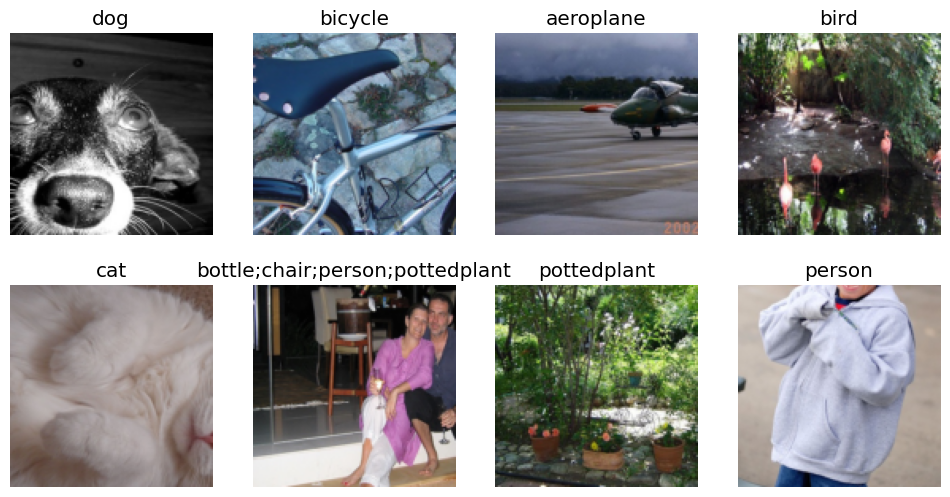

In [32]:
dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_y=get_y,
    get_x=get_x,
    splitter=splitter,
    item_tfms=RandomResizedCrop(128, min_scale=0.35)
)
dls = dblock.dataloaders(df)
dls.show_batch(nrows=2, ncols=4)

In [33]:
dblock.summary(df)

Setting-up type transforms pipelines
0     000005.jpg           chair      True
1     000007.jpg             car      True
2     000009.jpg    horse person      True
3     000012.jpg             car     False
4     000016.jpg         bicycle      True
...          ...             ...       ...
5006  009954.jpg    horse person      True
5007  009955.jpg            boat      True
5008  009958.jpg  person bicycle      True
5009  009959.jpg             car     False
5010  009961.jpg             dog     False

[5011 rows x 3 columns]
Found 5011 items
2 datasets of sizes 2501,2510
Setting up Pipeline: get_x -> PILBase.create
Setting up Pipeline: get_y -> MultiCategorize -- {'vocab': None, 'sort': True, 'add_na': False}
 -> OneHotEncode -- {'c': None}


Building one sample
  Pipeline: get_x -> PILBase.create
    starting from
      fname       000012.jpg
labels             car
is_valid         False
Name: 3, dtype: object
    applying get_x gives
      /root/.fastai/data/pascal_2007/train/000

### Binary Cross-Entropy (BCE)

Let's get a simple model using resnet18, then use that to explore how we arrive at BCE.

In [34]:
learn = vision_learner(dls, resnet18)
x, y = to_cpu(dls.train.one_batch())
x.shape, y.shape

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s] 


(torch.Size([64, 3, 128, 128]), torch.Size([64, 20]))

`.one_batch()` gives one mini-batch of data and corresponding labels. So now let's get the model's final activations for the mini-batch.

In [35]:
activs = learn.model(x)
activs.shape

torch.Size([64, 20])

Notice that the shape here matches the shape of `y` from earlier. That's expected because the model is making predictions that are supposed to get as close to `y` as possible. Looking at the first one:

In [36]:
activs[0]

TensorImage([-0.6604,  3.7083, -1.5740, -0.6980,  0.5220, -0.9594, -1.8903, -0.1805, -0.1008,  1.8911,  1.3607,  1.3528,  0.8708,  4.3651,  0.6839,  1.0118,  0.4205,  2.2555, -1.4704, -0.6334],
            grad_fn=<AliasBackward0>)

One thing is immediately obvious: the activations have not been sigmoid-ed or softmax-ed. Which of these 2 should we use?

Given that we're dealing with a multilabel classification task, we can't use softmax because it pushes the most confident prediction towards 1 and all other predictions towards 0. That's why it's well-suited to single-label classification tasks. In this case, we will need to use the sigmoid for each individual activation. That, however, immediately raises the question of what loss function to use. In this case, we can't use NLL like in the last chapter because it's not appropriate for a multilabel classification problem like this one.

In the case of NLL, we applied 2 transformations to softmax:
- logarithm so that the range of individual loss values is between 0 and ➖♾️
- multiplication by -1 to flip the range to between 0 and ➕♾️

In this case, loss can be captured as the distance from the correct prediction after sigmoid transformation for each activation. In other words that same definition of `mnist_loss` from chapter 4 applies here:

```python
def mnist_loss(preds, targ):
    preds = preds.sigmoid()
    return torch.where(targ == 1, 1-preds, preds).mean()
```

The first difference is that now we have to work with predictions for multiple classes instead of just 1. The next difference is to apply the same 2 transformations applied to softmax as seen in NLL.

In [37]:
def binary_cross_entropy(preds, targ):
    preds = preds.sigmoid()
    return -torch.where(targ == 1, preds, 1 - preds).log().mean()

Notice a subtle difference: when `targ == 1`, BCE uses `preds` instead of `1 - preds`. That falls directly out of the effect of applying the log function. Values that are closer to 0 give log values that go towards infinity, whereas values that are closer to 1 give log values closer to 0. Because we want good predictions to have low loss values, we use `preds` for the values closer to `1` and `1 - preds` for the values closer to `0`. In the case of `mnist_loss`, we didn't need to do this because we weren't applying the log transformation.

This function has a few versions within pytorch:
- `F.binary_cross_entropy` and `nn.BCELoss` are the functional and modular variants, respectively, of the function that do not perform the initial sigmoid operation. To use these variants, you should pass in sigmoid-transformed logits.
- `F.binary_cross_entropy_with_logits` and `nn.BCEWithLogitsLoss` are the functional and modular variants, respectively, of the function that perform the initial sigmoid operation. These are the variants you'll normally use.

In [44]:
torch.tensor(activs), torch.tensor(y)

/tmp/ipykernel_57/2705954763.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(activs), torch.tensor(y)


(tensor([[-0.6604,  3.7083, -1.5740,  ...,  2.2555, -1.4704, -0.6334],
         [ 0.6226,  0.7485, -0.1068,  ..., -0.6873, -1.6742,  0.8739],
         [ 3.0112, -1.6422, -0.9969,  ..., -0.1706,  0.4786,  0.3928],
         ...,
         [-0.7974,  2.0540,  3.3011,  ...,  1.6911,  3.6531,  0.4978],
         [-3.6561, -2.0431, -4.2319,  ..., -1.5965, -1.7815, -0.3101],
         [-0.3025,  2.5959, -2.5695,  ...,  2.0789, -2.9004,  0.2895]]),
 tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]))

In [47]:
loss_func = nn.BCEWithLogitsLoss()
loss = loss_func(activs.as_subclass(torch.Tensor), y.as_subclass(torch.Tensor))
loss

tensor(1.0531, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

Using `activs.as_subclass(torch.Tensor), y.as_subclass(torch.Tensor)` is necessary for compatibility with newer versions of pytorch.

Note that we don't actually have to specify this specific loss function in this case, because FastAI will detect the usage of the `MultiCategoryBlock` and choose this loss function by default.

Another change we have to make is to the metric function that we use. Up until now, we have been using accuracy because we were only caring about a single class prediction. Even when dealing with binary classification, we only cared about one output class in terms of accuracy because the inverse corresponded to the other class. Similarly, in the case of single-label classification with multiple categories, we still only cared about one final class because every input image corresponded to only one label.

Now, because we have to classify multiple categories within the same input image, we can no longer rely on the accuracy of identifying just one category. We have to modify the accuracy metric to identify all the categories that should be present and ensure it does not identify categories that are not present.

The accuracy metric for single-label classification looks like this:

```python
def accuracy(preds, targ, axis=-1):
    pred = preds.argmax(dim=axis)
    return (pred == targ).float().mean()
```

To make that work with multiple categories, we have to ditch the use of `.argmax()` and also select a threshold above which the predictions are deemed to be positive or negative:

```python
def accuracy_multi(preds, targ, threshold=0.5, sigmoid=True):
    if sigmoid:
        preds = preds.sigmoid()
    return ((preds > threshold) == targ.bool()).float().mean()
```

Even though it may seem intuitive to use 0.5 as the threshold, that's not always the right choice. Some training sets may not contain enough clear instances of a label for the model to build up ideal confidence levels, so it may be that lower confidence values than 0.5 actually still correctly indicate the presence of a label and give the best performance for the chosen dataset. The best way to resolve this is to test how the model performs on a range of thresholds. Let's start with a threshold of `0.2`.

In [ ]:
learn = vision_learner(dls, resnet50, metrics=partial(accuracy_multi(thresh=0.2)))
learn.fine_tune(3, base_lr=3e-3, freeze_epochs=4)

Picking a lower threshold might lead to false positives that worsen performance. We'll use `.validate()` to return validation and loss metrics.

In [ ]:
learn.metrics = partial(accuracy_multi(thresh=0.1))
learn.validate()

Picking a higher threshold would limit the model to only the highest confidence predictions, which can also limit performance.

In [ ]:
learn.metrics = partial(accuracy_multi(thresh=0.99))
learn.validate()